# ⚾ 신뢰구간 점검: 신뢰구간 다시 내기 (투수 cluster 부트스트랩, 시드 없는 대조군)

* **작성자:** CY
* **작성일:** 2026-10-05
* **배경:** 지금까지의 순수 감소 신뢰구간에는 두 가지 문제가 있습니다.
  1. **이벤트를 서로 독립으로 가정했습니다.** 같은 투수·같은 경기의 이벤트가 반복해서 들어가므로 실제 불확실성은 더 큽니다.
  2. **대조군을 시드 하나로 한 번만 뽑았습니다(1:1).** 어떤 대조군이 뽑혔는지에 따라 값이 달라지는데, 이 변동은 신뢰구간에 들어 있지 않습니다. 같은 M0인데 오즈비가 0.286(원본 데이터)과 0.304(CSV)로 다른 것도 이 때문입니다.
* **이렇게 바꿉니다.**
  * **시드 없는 대조군(가중):** 칸(층)마다 조건에 맞는 `field_out`을 **전부** 쓰고, 칸별 장타 수에 비례해 가중합니다. 뽑지 않으니 시드가 없습니다. 장타도 대조군이 있는 칸이면 모두 씁니다.
  * **투수 cluster 부트스트랩:** 투수를 복원추출(1,000회)해 신뢰구간을 다시 냅니다.
  * **시드 퍼짐 확인:** 기존 1:1 추출을 100개 시드로 반복해 값이 얼마나 움직이는지 봅니다. 오즈비는 10개 시드로 확인합니다.
  * 타구 질 칸별 비교(노트북 04)도 같은 부트스트랩으로 다시 냅니다.
* 이벤트는 노트북 04의 벡터 계산(`hit_quality.build_batted_ball_events`)으로 만들어, 대조군 전체를 몇 초 안에 계산합니다.

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src.analysis.avoidance_stats import compute_season_usage_rate
from src.analysis.hit_quality import XWOBA, add_prior_game_usage, add_xwoba_quartile, build_batted_ball_events
from src.analysis.robust_inference import (
    bootstrap_ci, cluster_bootstrap_cells, cluster_bootstrap_did, sample_1to1, weighted_did,
)
from src.analysis.situation_matching import LADDER_LABELS, LADDER_STEPS, MODES, add_situation_columns
from src.preprocessing.research_sample import KEY_COLUMNS, list_research_csvs

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
OUT_DIR = '../data/processed'
FIG_DIR = '../data/processed/figures'
os.makedirs(FIG_DIR, exist_ok=True)
MODE_LABELS = {'same_batter': '재대결 (메인)', 'next_batter': '다음 타자 (보조)'}
BASELINES = {'season_usage_rate': 'season', 'baseline_usage': 'game'}
N_BOOT = 1000

## 1. 데이터와 이벤트

In [2]:
LOAD_COLUMNS = [
    'game_pk', 'game_date', 'at_bat_number', 'pitch_number', 'pitcher', 'batter', 'stand', 'p_throws',
    'pitch_type', 'events', 'balls', 'strikes', 'outs_when_up', 'inning', 'inning_topbot',
    'on_1b', 'on_2b', 'on_3b', 'home_score', 'away_score', 'launch_speed', 'launch_angle', XWOBA,
]
frames = [pd.read_csv(p, usecols=LOAD_COLUMNS, encoding='utf-8-sig', low_memory=False) for p in list_research_csvs()]
pitches = pd.concat(frames, ignore_index=True)
pitches['season'] = pd.to_datetime(pitches['game_date']).dt.year
assert len(pitches) == 3_592_302 and not pitches.duplicated(KEY_COLUMNS).any()
pitches = add_prior_game_usage(add_situation_columns(pitches))
season_usage = compute_season_usage_rate(pitches)

groups = {}
for mode in MODES:
    ev = build_batted_ball_events(pitches, season_usage, mode)
    ev = ev[ev['next_ab_pitch_count'] > 0]
    xbh = ev[ev['outcome'].isin(['2·3루타', '홈런'])].copy()
    ctrl = ev[ev['outcome'] == '아웃'].copy()
    groups[mode] = (xbh, ctrl)
    print(f'[{MODE_LABELS[mode]}] 장타 {len(xbh):,}건, 대조군 후보(field_out) {len(ctrl):,}건')

# 노트북 03(이벤트 빌더)과 같은 값인지 확인: 재대결 장타 수와 M0 장타 쪽 평균
xbh_sb = groups['same_batter'][0]
assert len(xbh_sb) == 27_371, len(xbh_sb)
ladder03 = pd.read_csv(f'{OUT_DIR}/ladder_pure_reduction.csv').set_index(['mode', 'step'])
x_mean = (xbh_sb['season_usage_rate'] - xbh_sb['same_type_share']).mean()
assert abs(x_mean - ladder03.loc[('same_batter', 'M0'), 'season_xbh_diff']) < 1e-9, x_mean
print('노트북 03과 장타 쪽 값 일치')

[재대결 (메인)] 장타 27,371건, 대조군 후보(field_out) 146,500건


[다음 타자 (보조)] 장타 66,017건, 대조군 후보(field_out) 240,883건
노트북 03과 장타 쪽 값 일치


## 2. 순수 감소: 1:1 표본·독립 가정 CI vs 가중 대조군·투수 cluster CI

* `net_1to1`, `ci_1to1`: 노트북 03 값 (시드 1개, 이벤트 독립 가정)
* `net_w`, `ci_cluster`: 대조군 전체 가중 + 투수 cluster 부트스트랩 (퍼센타일 95% CI)
* `width_ratio`: cluster CI 폭 / 기존 CI 폭

In [3]:
rows = []
for mode in MODES:
    xbh, ctrl = groups[mode]
    for base, tag in BASELINES.items():
        x = xbh[xbh[base].notna()].assign(diff=lambda d: d[base] - d['same_type_share'])
        c = ctrl[ctrl[base].notna()].assign(diff=lambda d: d[base] - d['same_type_share'])
        for step, strata in LADDER_STEPS.items():
            r = weighted_did(x, c, list(strata))
            boot = cluster_bootstrap_did(x, c, list(strata), n_boot=N_BOOT, seed=20261005)
            lo, hi = bootstrap_ci(r['net'], boot)
            old = ladder03.loc[(mode, step)]
            rows.append({
                'mode': mode, 'baseline': tag, 'step': step,
                'n_xbh': r['n_xbh'], 'retention': r['n_xbh'] / r['n_xbh_all'], 'n_ctrl': r['n_ctrl'],
                'net_1to1': old[f'{tag}_net'], 'ci_1to1_low': old[f'{tag}_ci_low'], 'ci_1to1_high': old[f'{tag}_ci_high'],
                'net_w': r['net'], 'ci_cluster_low': lo, 'ci_cluster_high': hi,
                'width_ratio': (hi - lo) / (old[f'{tag}_ci_high'] - old[f'{tag}_ci_low']),
            })
robust = pd.DataFrame(rows).set_index(['mode', 'baseline', 'step'])
show = robust.copy()
pct = [c for c in show.columns if c.startswith(('net', 'ci'))]
show[pct] *= 100
display(show.round(2))
robust.to_csv(f'{OUT_DIR}/robust_pure_reduction.csv')

n_xbh  retention  n_ctrl  net_1to1  ci_1to1_low  ci_1to1_high  net_w  ci_cluster_low  ci_cluster_high  width_ratio
mode        baseline step                                                                                                                    
same_batter season   M0    27371       1.00  146500     14.39        13.94         14.84  14.36           13.90            14.81         1.02
                     M1    27371       1.00  146460     14.50        14.05         14.94  14.36           13.89            14.80         1.03
                     M2    27240       1.00  144252     14.41        13.96         14.86  14.32           13.86            14.79         1.04
                     M3    26951       0.98  139321     14.34        13.89         14.80  14.31           13.83            14.76         1.02
            game     M0    26846       1.00  144435     15.35        14.84         15.86  15.30           14.81            15.79         0.96
                     M1    26846       1.00  144395     15.34        14.83         15.85  15.30           14.81            15.80         0.97
                     M2    26717       1.00  142201     15.14        14.63         15.66  15.17           14.67            15.66         0.96
                     M3    26429       0.98  137265     15.21        14.70         15.73  15.13           14.63            15.62         0.96
next_batter season   M0    66017       1.00  240883      6.80         6.50          7.09   6.89            6.64             7.17         0.90
                     M1    46105       0.70  240864      6.77         6.42          7.12   6.71            6.41             7.01         0.86
                     M2    46043       0.70  239856      6.84         6.49          7.20   6.77            6.47             7.08         0.87
                     M3    45654       0.69  235615      6.69         6.34          7.04   6.75            6.43             7.05         0.89
            game     M0    64736       1.00  235123      7.13         6.80          7.46   7.26            6.97             7.54         0.85
                     M1    44952       0.69  235104      7.35         6.95          7.76   7.29            6.94             7.61         0.83
                     M2    44890       0.69  234099      7.34         6.94          7.75   7.26            6.91             7.58         0.83
                     M3    44494       0.69  229841      7.17         6.77          7.58   7.23            6.84             7.54         0.87

### 2-1. 신뢰구간 폭 분해: 대조군을 늘린 효과 vs 투수로 묶은 효과

2절의 폭 비율에는 두 변화가 섞여 있습니다(대조군 약 5배 증가 → 좁아짐, 투수 cluster → 넓어짐). M3·시즌 baseline에서 **같은 가중 추정치**로 부트스트랩 단위만 바꿔 봅니다: 이벤트(독립 가정), 투수-경기, 투수.

In [4]:
width_rows = []
for mode in MODES:
    xbh, ctrl = groups[mode]
    x = xbh.assign(diff=xbh['season_usage_rate'] - xbh['same_type_share']).dropna(subset=['diff'])
    c = ctrl.assign(diff=ctrl['season_usage_rate'] - ctrl['same_type_share']).dropna(subset=['diff'])
    allev = pd.concat([x, c], ignore_index=True)
    allev['row'] = np.arange(len(allev))
    allev['pitcher_game'] = allev['game_pk'].astype(str) + '_' + allev['pitcher'].astype(str)
    x, c = allev.iloc[:len(x)], allev.iloc[len(x):]
    strata = list(LADDER_STEPS['M3'])
    est = weighted_did(x, c, strata)['net']
    for unit, label in [('row', '이벤트(독립)'), ('pitcher_game', '투수-경기'), ('pitcher', '투수')]:
        lo, hi = bootstrap_ci(est, cluster_bootstrap_did(x, c, strata, cluster=unit, n_boot=N_BOOT, seed=20261005))
        width_rows.append({'mode': mode, 'unit': label, 'width_pp': (hi - lo) * 100})
widths = pd.DataFrame(width_rows).pivot(index='mode', columns='unit', values='width_pp')[['이벤트(독립)', '투수-경기', '투수']]
widths['1:1 독립(노트북 03)'] = [(ladder03.loc[(m, 'M3'), 'season_ci_high'] - ladder03.loc[(m, 'M3'), 'season_ci_low']) * 100 for m in widths.index]
widths['투수/이벤트'] = widths['투수'] / widths['이벤트(독립)']
display(widths.round(3))
widths.to_csv(f'{OUT_DIR}/robust_ci_width_decomposition.csv')

unit,이벤트(독립),투수-경기,투수,1:1 독립(노트북 03),투수/이벤트
mode,,,,,
next_batter,0.545,0.589,0.626,0.703,1.149
same_batter,0.753,0.705,0.926,0.904,1.229


## 3. 시드에 따라 얼마나 움직이나 (1:1 추출 100회, 시즌 baseline)

같은 조건에서 시드만 바꿔 1:1 대조군을 100번 뽑습니다. 이 퍼짐(표준편차)이 독립 가정 표준오차에 비해 얼마나 큰지 봅니다.

In [5]:
seed_rows, seed_nets = [], {}
for mode in MODES:
    xbh, ctrl = groups[mode]
    x = xbh.assign(diff=xbh['season_usage_rate'] - xbh['same_type_share']).dropna(subset=['diff'])
    c = ctrl.assign(diff=ctrl['season_usage_rate'] - ctrl['same_type_share']).dropna(subset=['diff'])
    for step in ['M0', 'M3']:
        strata = list(LADDER_STEPS[step])
        nets = []
        for seed in range(100):
            xs, cs = sample_1to1(x, c, strata, seed)
            nets.append(xs['diff'].mean() - cs['diff'].mean())
        nets = np.array(nets)
        seed_nets[mode, step] = nets
        old = ladder03.loc[(mode, step)]
        naive_se = (old['season_ci_high'] - old['season_ci_low']) / (2 * 1.96)
        seed_rows.append({'mode': mode, 'step': step, 'mean': nets.mean(), 'sd_over_seeds': nets.std(ddof=1),
                          'min': nets.min(), 'max': nets.max(), 'naive_se': naive_se,
                          'weighted_net': robust.loc[(mode, 'season', step), 'net_w']})
seeds = pd.DataFrame(seed_rows).set_index(['mode', 'step'])
display((seeds * 100).round(3))
seeds.to_csv(f'{OUT_DIR}/robust_seed_spread.csv')

mean  sd_over_seeds     min     max  naive_se  weighted_net
mode        step                                                               
same_batter M0    14.379          0.171  13.957  14.777     0.228        14.361
            M3    14.317          0.160  13.991  14.690     0.231        14.311
next_batter M0     6.891          0.104   6.647   7.148     0.149         6.889
            M3     6.731          0.119   6.422   7.023     0.179         6.753

## 4. 오즈비도 시드에 따라 움직이나 (재대결, 10개 시드, R)

M0와 M3에서 1:1 대조군을 10번 다시 뽑아 혼합모델 `group` 오즈비를 다시 적합합니다. 공식은 노트북 03과 같습니다.

In [6]:
FORMULA = (
    'reused_same_type ~ group * baseline_usage + balls + strikes + outs_when_up + score_diff '
    '+ stand + pitch_family + factor(season) + (0 + group | pitcher)'
)
REQUIRED = ['reused_same_type', 'baseline_usage', 'balls', 'strikes', 'outs_when_up', 'score_diff',
            'stand', 'pitch_family', 'season', 'pitcher']
try:
    from src.analysis.glmer_runner import extract_fixed_effects_table, fit_glmer
    HAS_R = True
except Exception as e:
    HAS_R = False
    print('R을 쓸 수 없어 건너뜁니다:', e)

or_seeds = None
if HAS_R:
    xbh, ctrl = groups['same_batter']
    rows = []
    for step in ['M0', 'M3']:
        strata = list(LADDER_STEPS[step])
        for seed in range(10):
            xs, cs = sample_1to1(xbh, ctrl, strata, seed)
            combined = pd.concat([xs.assign(group=1), cs.assign(group=0)], ignore_index=True)
            combined = combined.dropna(subset=REQUIRED)[REQUIRED + ['group']].copy()
            combined['pitcher'] = combined['pitcher'].astype(str)
            fit_glmer(combined, FORMULA)
            fe = extract_fixed_effects_table().set_index('term')
            rows.append({'step': step, 'seed': seed, 'n': len(combined), 'group_or': fe.loc['group', 'odds_ratio'],
                         'or_low': fe.loc['group', 'or_ci_low'], 'or_high': fe.loc['group', 'or_ci_high']})
    or_seeds = pd.DataFrame(rows)
    display(or_seeds.groupby('step')['group_or'].agg(['mean', 'std', 'min', 'max']).round(4))
    or_seeds.to_csv(f'{OUT_DIR}/robust_or_seeds.csv', index=False)

R callback write-console: 필요한 패키지를 로딩중입니다: Matrix
  


,mean,std,min,max
step,,,,
M0,0.2924,0.0077,0.2789,0.3043
M3,0.2924,0.0069,0.2817,0.3019


## 5. 타구 질 칸별 비교 다시 내기 (재대결·다음 타자, 시즌 baseline)

노트북 04의 결과 × xwOBA 분위 표를 투수 cluster 부트스트랩 CI로 다시 냅니다(기준: 약한 아웃).

In [7]:
hq_rows = []
for mode in MODES:
    ev = build_batted_ball_events(pitches, season_usage, mode)
    ev = add_xwoba_quartile(ev)
    ev = ev[ev['season_usage_rate'].notna() & ev['xwoba_q'].notna()].copy()
    ev['diff'] = ev['season_usage_rate'] - ev['same_type_share']
    t = cluster_bootstrap_cells(ev, ['outcome', 'xwoba_q'], ('아웃', 'Q1'), n_boot=N_BOOT, seed=20261005)
    hq_rows.append(t.assign(mode=mode))
hq = pd.concat(hq_rows, ignore_index=True)
old04 = pd.read_csv(f'{OUT_DIR}/hit_quality_xwoba_cells.csv')
old04 = old04[old04['baseline'] == 'season_usage_rate'].set_index(['mode', 'outcome', 'xwoba_q'])
hq = hq.join(old04[['ci_low', 'ci_high']].rename(columns=lambda c: c + '_naive'), on=['mode', 'outcome', 'xwoba_q'])
hq['width_ratio'] = (hq['ci_high'] - hq['ci_low']) / (hq['ci_high_naive'] - hq['ci_low_naive'])
show = hq.copy()
show[['vs_ref', 'ci_low', 'ci_high', 'ci_low_naive', 'ci_high_naive']] *= 100
display(show.round(2))
hq.to_csv(f'{OUT_DIR}/robust_hit_quality_cells.csv', index=False)
print('CI 폭 비율(cluster / 기존) 중앙값:', hq['width_ratio'].median().round(2))

,outcome,xwoba_q,n,vs_ref,ci_low,ci_high,mode,ci_low_naive,ci_high_naive,width_ratio
0,2·3루타,Q1,447,3.67,0.98,6.18,same_batter,1.03,6.32,0.98
1,2·3루타,Q2,1643,9.14,7.96,10.33,same_batter,7.87,10.42,0.93
2,2·3루타,Q3,4780,12.65,11.87,13.44,same_batter,11.90,13.41,1.04
3,2·3루타,Q4,9634,14.95,14.34,15.60,same_batter,14.41,15.49,1.18
4,단타,Q1,1097,-0.67,-2.42,1.09,same_batter,-2.45,1.11,0.99
5,단타,Q2,7752,1.74,1.15,2.43,same_batter,1.05,2.44,0.92
6,단타,Q3,18130,8.35,7.85,8.86,same_batter,7.89,8.82,1.08
7,단타,Q4,22865,10.90,10.36,11.42,same_batter,10.49,11.32,1.29
8,아웃,Q1,54364,0.00,0.00,0.00,same_batter,-0.35,0.35,0.00
9,아웃,Q2,46154,-1.11,-1.47,-0.73,same_batter,-1.48,-0.75,1.02


CI 폭 비율(cluster / 기존) 중앙값: 1.02


## 6. 그래프

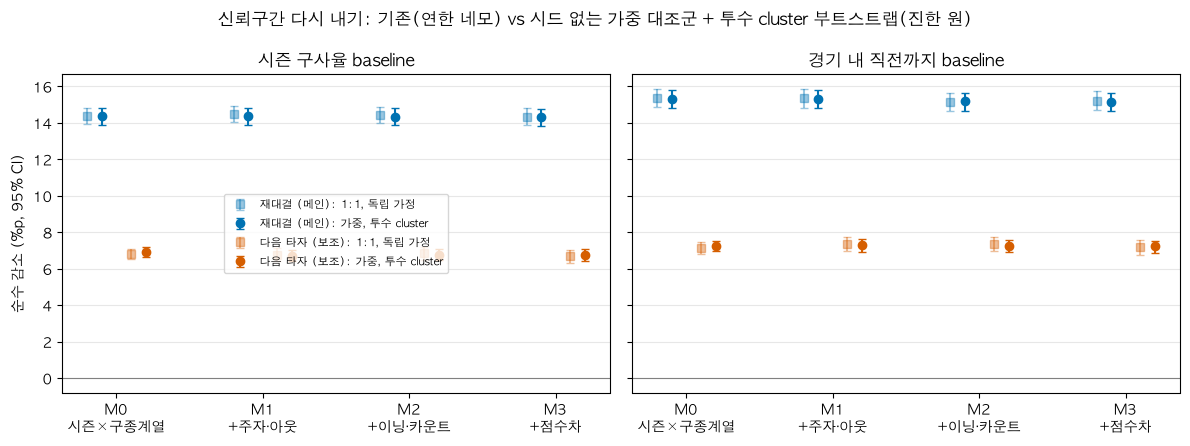

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
colors = {'same_batter': '#0072B2', 'next_batter': '#D55E00'}
steps = list(LADDER_STEPS)
xs = np.arange(len(steps))
for ax, (tag, title) in zip(axes, [('season', '시즌 구사율 baseline'), ('game', '경기 내 직전까지 baseline')]):
    for i, mode in enumerate(MODES):
        d = robust.loc[(mode, tag)]
        off = (i - 0.5) * 0.3
        y0 = d['net_1to1'] * 100
        ax.errorbar(xs + off - 0.05, y0, yerr=[y0 - d['ci_1to1_low'] * 100, d['ci_1to1_high'] * 100 - y0],
                    fmt='s', capsize=3, color=colors[mode], alpha=0.4, label=f'{MODE_LABELS[mode]}: 1:1, 독립 가정')
        y1 = d['net_w'] * 100
        ax.errorbar(xs + off + 0.05, y1, yerr=[y1 - d['ci_cluster_low'] * 100, d['ci_cluster_high'] * 100 - y1],
                    fmt='o', capsize=3, color=colors[mode], label=f'{MODE_LABELS[mode]}: 가중, 투수 cluster')
    ax.set_xticks(xs, [f'{s}\n{LADDER_LABELS[s]}' for s in steps])
    ax.set_title(title)
    ax.axhline(0, color='grey', lw=0.8)
    ax.grid(axis='y', alpha=0.3)
axes[0].set_ylabel('순수 감소 (%p, 95% CI)')
axes[0].legend(fontsize=8, loc='center')
fig.suptitle('신뢰구간 다시 내기: 기존(연한 네모) vs 시드 없는 가중 대조군 + 투수 cluster 부트스트랩(진한 원)')
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/robust_pure_reduction.png', dpi=150)
plt.show()

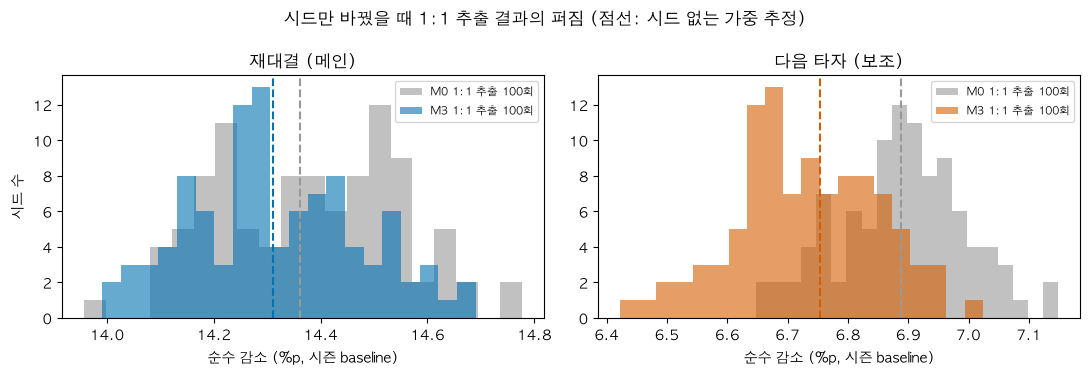

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, mode in zip(axes, MODES):
    for step, color in [('M0', '#999999'), ('M3', colors[mode])]:
        ax.hist(seed_nets[mode, step] * 100, bins=20, alpha=0.6, color=color, label=f'{step} 1:1 추출 100회')
        ax.axvline(robust.loc[(mode, 'season', step), 'net_w'] * 100, color=color, ls='--', lw=1.5)
    ax.set_title(MODE_LABELS[mode])
    ax.set_xlabel('순수 감소 (%p, 시즌 baseline)')
    ax.legend(fontsize=8)
axes[0].set_ylabel('시드 수')
fig.suptitle('시드만 바꿨을 때 1:1 추출 결과의 퍼짐 (점선: 시드 없는 가중 추정)')
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/robust_seed_spread.png', dpi=150)
plt.show()

## 7. 해석

* **결론이 바뀌지 않습니다.** 시드 없는 가중 대조군 + 투수 cluster CI로 다시 내도, 재대결 M3 순수 감소는 **14.31%p** [13.83, 14.76](시즌 baseline), **15.13%p** [14.63, 15.62](경기 내 baseline)이고, 다음 타자 M3는 **6.75%p** [6.43, 7.05]입니다. 노트북 03 값과의 차이는 0.1%p 안팎입니다. M0→M3 사다리에서 결과가 거의 변하지 않는다는 결론도 그대로입니다.
* **투수로 묶으면 CI가 넓어지는 것은 맞습니다.** 같은 추정치에서 부트스트랩 단위만 바꾸면, 재대결은 이벤트 단위 대비 투수 단위 CI가 약 **1.23배**, 다음 타자는 약 1.15배 넓습니다. 투수-경기 단위로 묶었을 때는 거의 넓어지지 않아(재대결 0.94배, 다음 타자 1.08배), 상관은 한 경기 안보다 **같은 투수의 성향**에서 옵니다.
* **하지만 대조군을 전부 쓰면 그만큼 좁아져서, 최종 CI 폭은 기존과 비슷합니다.** 재대결 M3 기준 기존 0.90%p → 새 0.93%p, 다음 타자 0.70%p → 0.63%p. 1:1 추출은 `field_out` 후보(재대결 146,500건)의 약 5분의 1만 썼습니다. 전부 가중해 쓰면 대조군 쪽 잡음이 줄어 클러스터링으로 넓어진 몫을 상쇄합니다. 그래서 기존 CI는 "틀린 가정 위에서 우연히 비슷한 폭"이었고, 이제는 **올바른 가정으로 같은 폭**을 얻었습니다. 보고서에는 새 값(가중 + 투수 cluster)을 씁니다.
* **시드만 바꿔도 순수 감소가 0.16~0.17%p(표준편차) 움직입니다.** 100번 추출하면 재대결 M0가 13.96~14.78%p 사이에 퍼지고, 이 퍼짐은 기존 표준오차(0.23%p)의 약 70%입니다. 결론에는 영향이 없지만, 1:1 추출 한 번의 값을 소수점 둘째 자리까지 인용하는 것은 의미가 없습니다. 가중 추정은 시드가 없어 이 문제가 없습니다.
* **오즈비의 0.286 vs 0.304 차이는 시드 때문입니다.** 1:1 대조군을 10번 다시 뽑으면 재대결 `group` 오즈비가 M0 0.279~0.304(평균 0.292), M3 0.282~0.302(평균 0.292)로 움직입니다. 원본 데이터 값 0.286과 CSV 값 0.304는 모두 이 범위 안이므로, 데이터 차이가 아니라 추출 차이입니다. 보고서에는 **약 0.29**로 씁니다.
* **타구 질 칸별 CI도 거의 같습니다.** 투수 cluster CI 폭은 기존의 0.9~1.3배(중앙값 1.02)이고, 표본이 많은 Q4 칸에서 가장 넓어집니다(1.1~1.3배). 노트북 04의 결론(잘 맞은 아웃도 피함, 결과가 나쁠수록 더 피함, 홈런은 타구 질과 거의 무관)은 모두 유지됩니다.
* **가중 방식에서 바뀐 표본.** 장타를 칸별 대조군 수에 맞춰 줄이지 않으므로, 재대결 M3에서 장타 26,951건(기존 26,816건)을 씁니다. 다음 타자 M1~M3의 유지율이 약 70%인 것은 같습니다(2아웃 장타에 대조군이 없음, 향후 분석의 다음 타자 재정의에서 다룸).
* **한계.** 혼합모델 오즈비는 1:1 표본에서만 적합했습니다(가중 glmer는 하지 않음). 오즈비 CI는 모델 기반이며, 시드 퍼짐(표준편차 약 0.007)을 함께 보고합니다.